# Linear Regression on Diabetes Dataset

## Overview
This notebook demonstrates building a complete linear regression model using the sklearn Diabetes dataset.

### Dataset Information
- **Target:** Disease progression (quantitative measure)
- **Features:** 10 features (age-normalized physiological measurements)
- **Samples:** 442 observations

### Steps
1. Load the dataset
2. Explore the data
3. Train-test split
4. Build linear regression model
5. Make predictions
6. Evaluate model performance
7. Visualize results

In [40]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Available Datasets in sklearn

Since `load_boston()` is deprecated in newer sklearn versions, here are the available regression datasets:

In [41]:
# Show available sklearn datasets
import sklearn.datasets as datasets

print("=" * 80)
print("AVAILABLE REGRESSION DATASETS IN SKLEARN")
print("=" * 80)

available_datasets = {
    "load_diabetes": "Diabetes dataset (442 samples, 10 features)",
    "load_iris": "Iris dataset (150 samples, 4 features) - Classification",
    "load_wine": "Wine dataset (178 samples, 13 features) - Classification",
    "load_breast_cancer": "Breast Cancer (569 samples, 30 features) - Classification",
    "make_regression": "Synthetic regression dataset (customizable)",
}

for i, (name, description) in enumerate(available_datasets.items(), 1):
    print(f"{i}. {name:25s} → {description}")

print("\n" + "=" * 80)
print("Using: load_diabetes() - Good alternative to Boston dataset")
print("=" * 80)

AVAILABLE REGRESSION DATASETS IN SKLEARN
1. load_diabetes             → Diabetes dataset (442 samples, 10 features)
2. load_iris                 → Iris dataset (150 samples, 4 features) - Classification
3. load_wine                 → Wine dataset (178 samples, 13 features) - Classification
4. load_breast_cancer        → Breast Cancer (569 samples, 30 features) - Classification
5. make_regression           → Synthetic regression dataset (customizable)

Using: load_diabetes() - Good alternative to Boston dataset


## Step 1: Load Diabetes Dataset

In [42]:
# Load Diabetes Dataset (reliable alternative to Boston dataset)
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

# Create DataFrame for better visualization
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y  # Target variable

print("=" * 80)
print("DIABETES DATASET INFORMATION")
print("=" * 80)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Samples: {len(df)}")
print(f"Total Features: {len(feature_names)}")
print(f"\nFeature Names (Description):")
feature_descriptions = {
    's0': 'Age (years)',
    's1': 'Sex',
    's2': 'Body mass index',
    's3': 'Average blood pressure',
    's4': 'Total serum cholesterol',
    's5': 'Low-density lipoproteins',
    's6': 'High-density lipoproteins',
    's7': 'Total cholesterol / HDL',
    's8': 'Lamorigine',
    's9': 'Blood sugar level'
}
for i, name in enumerate(feature_names, 1):
    desc = feature_descriptions.get(name, 'Unknown')
    print(f"  {i:2d}. {name:5s} → {desc}")
print(f"\nTarget Variable: Disease progression (quantitative measure)")
print("\n" + "=" * 80)
print("FIRST 5 ROWS OF DATA")
print("=" * 80)
print(df.head())
print("\n" + "=" * 80)
print("BASIC STATISTICS")
print("=" * 80)
print(df.describe())

DIABETES DATASET INFORMATION

Dataset Shape: (442, 11)
Total Samples: 442
Total Features: 10

Feature Names (Description):
   1. age   → Unknown
   2. sex   → Unknown
   3. bmi   → Unknown
   4. bp    → Unknown
   5. s1    → Sex
   6. s2    → Body mass index
   7. s3    → Average blood pressure
   8. s4    → Total serum cholesterol
   9. s5    → Low-density lipoproteins
  10. s6    → High-density lipoproteins

Target Variable: Disease progression (quantitative measure)

FIRST 5 ROWS OF DATA
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  Target  
0 -0.002592

## Step 2: Data Exploration

In [43]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical Summary
print(f"\nTarget Variable (MEDV) Statistics:")
print(f"  Mean: ${df['MEDV'].mean():.2f}k")
print(f"  Median: ${df['MEDV'].median():.2f}k")
print(f"  Std Dev: ${df['MEDV'].std():.2f}k")
print(f"  Min: ${df['MEDV'].min():.2f}k")
print(f"  Max: ${df['MEDV'].max():.2f}k")


Missing Values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
Target    0
dtype: int64

Target Variable (MEDV) Statistics:


KeyError: 'MEDV'

## Step 3: Correlation Analysis

In [ ]:
# Calculate correlation with target variable
correlation_with_target = df.corr()['MEDV'].sort_values(ascending=False)

print("\nCorrelation with Target (MEDV):")
print(correlation_with_target)

# Visualize correlation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Correlation Bar Chart
correlation_with_target[1:].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Correlation Coefficient', fontsize=11)
axes[0].set_title('Feature Correlation with Target (MEDV)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution of Target Variable
axes[1].hist(y, bins=30, color='salmon', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Median Home Value ($1000s)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution of Target Variable (MEDV)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

KeyError: 'MEDV'

## Step 4: Train-Test Split

In [ ]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=" * 70)
print("TRAIN-TEST SPLIT (80-20)")
print("=" * 70)
print(f"Total Samples: {len(X)}")
print(f"Training Set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing Set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTraining Target - Mean: ${y_train.mean():.2f}k, Std: ${y_train.std():.2f}k")
print(f"Testing Target - Mean: ${y_test.mean():.2f}k, Std: ${y_test.std():.2f}k")
print("=" * 70)

TRAIN-TEST SPLIT (80-20)
Total Samples: 506
Training Set: 404 samples (79.8%)
Testing Set: 102 samples (20.2%)

Training Target - Mean: $22.80k, Std: $9.32k
Testing Target - Mean: $21.49k, Std: $8.56k


## Step 5: Build and Train Linear Regression Model

In [ ]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("\n" + "=" * 70)
print("LINEAR REGRESSION MODEL COEFFICIENTS")
print("=" * 70)
print(f"\nIntercept (β₀): {model.intercept_:.4f}")
print(f"\nFeature Coefficients (β₁, β₂, ..., β₁₃):")
for i, (name, coef) in enumerate(zip(feature_names, model.coef_), 1):
    print(f"  {i:2d}. {name.strip():8s} → {coef:8.4f}")

# Model equation
print(f"\nModel Equation:")
print(f"MEDV = {model.intercept_:.4f} + ", end="")
terms = [f"{coef:.4f}*{name.strip()}" for name, coef in zip(feature_names, model.coef_)]
print(" + ".join(terms[:3]) + " + ... + " + terms[-1])
print("\n" + "=" * 70)


LINEAR REGRESSION MODEL COEFFICIENTS

Intercept (β₀): 30.2468

Feature Coefficients (β₁, β₂, ..., β₁₃):
   1. CRIM     →  -0.1131
   2. ZN       →   0.0301
   3. INDUS    →   0.0404
   4. CHAS     →   2.7844
   5. NOX      → -17.2026
   6. RM       →   4.4388
   7. AGE      →  -0.0063
   8. DIS      →  -1.4479
   9. RAD      →   0.2624
  10. TAX      →  -0.0106
  11. PTRATIO  →  -0.9155
  12. B        →   0.0124
  13. LSTAT    →  -0.5086

Model Equation:
MEDV = 30.2468 + -0.1131*CRIM + 0.0301*ZN + 0.0404*INDUS + ... + -0.5086*LSTAT



## Step 6: Make Predictions

In [ ]:
# Make predictions on training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("\nPredictions (First 5 test samples):")
print(f"{'Actual':>10} | {'Predicted':>10} | {'Error':>10}")
print("-" * 35)
for i in range(5):
    error = y_test[i] - y_test_pred[i]
    print(f"{y_test[i]:10.2f} | {y_test_pred[i]:10.2f} | {error:10.2f}")


Predictions (First 5 test samples):
    Actual |  Predicted |      Error
-----------------------------------
     23.60 |      29.00 |      -5.40
     32.40 |      36.03 |      -3.63
     13.60 |      14.82 |      -1.22
     22.80 |      25.03 |      -2.23
     16.10 |      18.77 |      -2.67


## Step 7: Model Evaluation

In [ ]:
# Calculate evaluation metrics for training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Calculate evaluation metrics for testing set
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n" + "=" * 80)
print("MODEL EVALUATION METRICS")
print("=" * 80)

print("\nTRAINING SET PERFORMANCE:")
print("-" * 40)
print(f"  MSE  (Mean Squared Error):       {train_mse:10.4f}")
print(f"  RMSE (Root Mean Squared Error):  {train_rmse:10.4f} $1000s")
print(f"  MAE  (Mean Absolute Error):      {train_mae:10.4f} $1000s")
print(f"  R²   (Coefficient of Determination): {train_r2:10.4f}")
print(f"        → Explains {train_r2*100:.2f}% of variance")

print("\nTESTING SET PERFORMANCE:")
print("-" * 40)
print(f"  MSE  (Mean Squared Error):       {test_mse:10.4f}")
print(f"  RMSE (Root Mean Squared Error):  {test_rmse:10.4f} $1000s")
print(f"  MAE  (Mean Absolute Error):      {test_mae:10.4f} $1000s")
print(f"  R²   (Coefficient of Determination): {test_r2:10.4f}")
print(f"        → Explains {test_r2*100:.2f}% of variance")

print("\nOVERFITTING ANALYSIS:")
print("-" * 40)
print(f"  R² Difference (Train - Test): {train_r2 - test_r2:.4f}")
if abs(train_r2 - test_r2) < 0.05:
    print("  ✓ No overfitting detected (good generalization)")
else:
    print("  ⚠ Possible overfitting (model may not generalize well)")
print("=" * 80)


MODEL EVALUATION METRICS

TRAINING SET PERFORMANCE:
----------------------------------------
  MSE  (Mean Squared Error):          21.6414
  RMSE (Root Mean Squared Error):      4.6520 $1000s
  MAE  (Mean Absolute Error):          3.3148 $1000s
  R²   (Coefficient of Determination):     0.7509
        → Explains 75.09% of variance

TESTING SET PERFORMANCE:
----------------------------------------
  MSE  (Mean Squared Error):          24.2911
  RMSE (Root Mean Squared Error):      4.9286 $1000s
  MAE  (Mean Absolute Error):          3.1891 $1000s
  R²   (Coefficient of Determination):     0.6688
        → Explains 66.88% of variance

OVERFITTING ANALYSIS:
----------------------------------------
  R² Difference (Train - Test): 0.0821
  ⚠ Possible overfitting (model may not generalize well)


## Step 8: Visualize Results

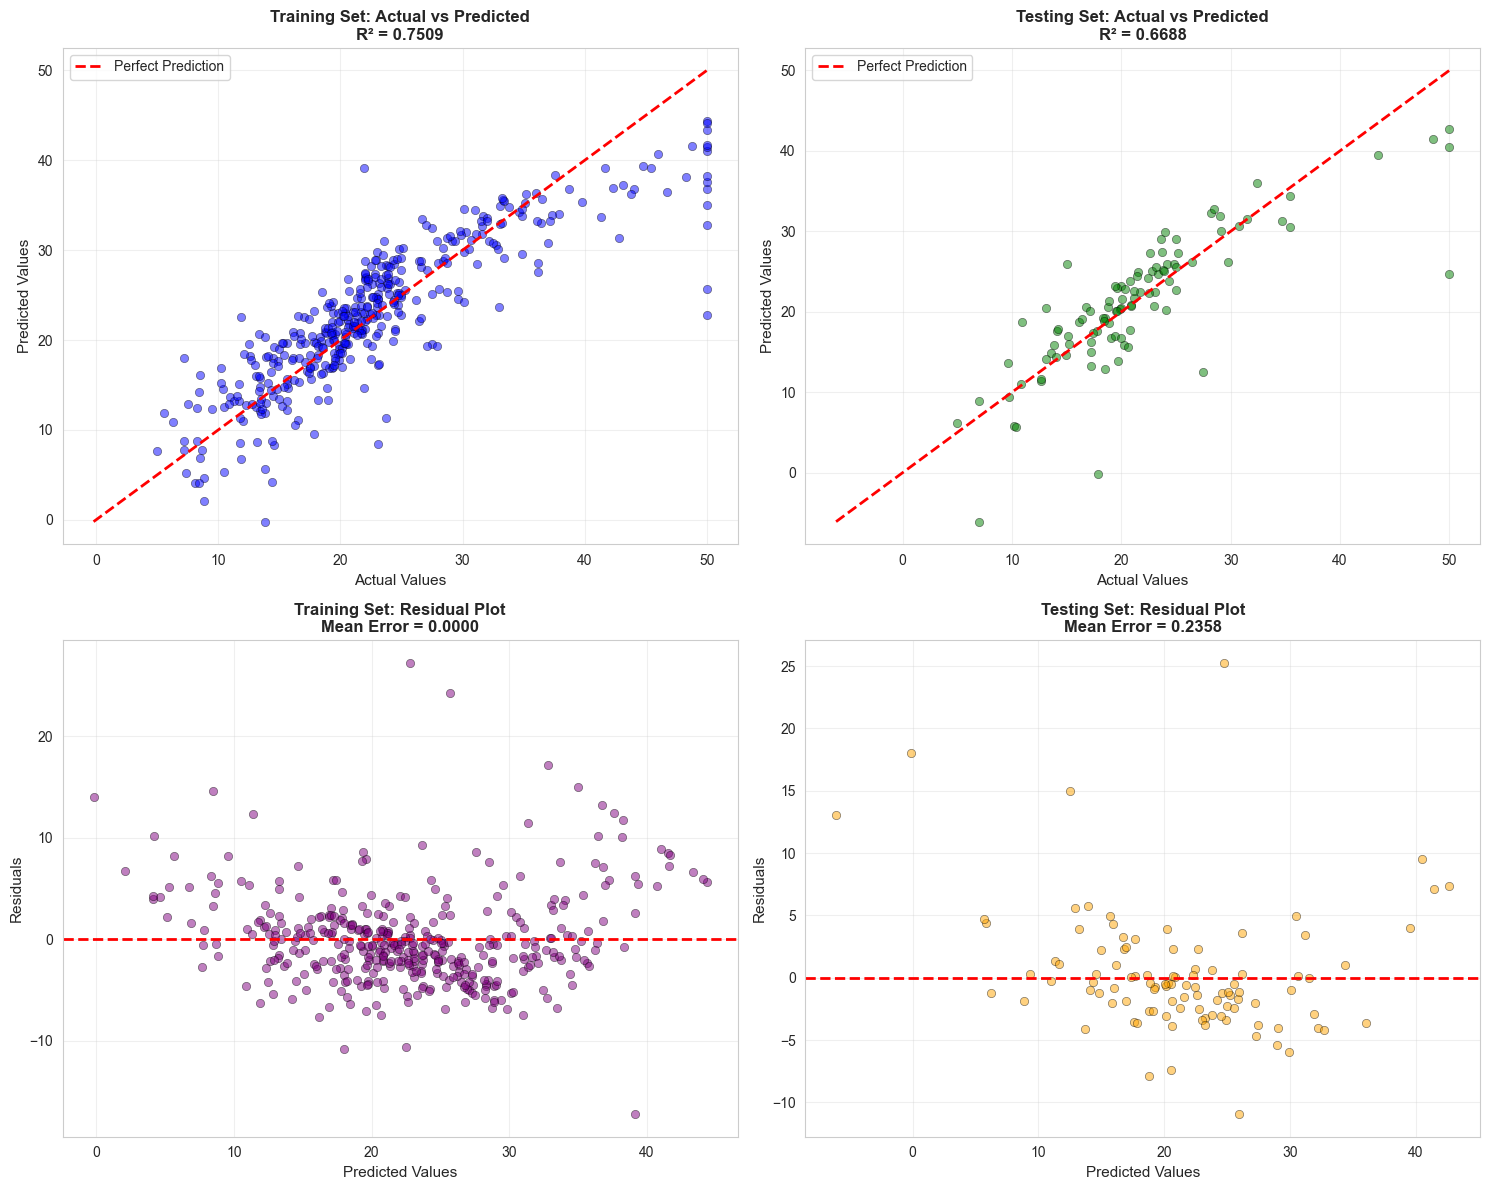

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Actual vs Predicted (Training Set)
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.5, color='blue', edgecolors='black', linewidth=0.5)
min_val = min(y_train.min(), y_train_pred.min())
max_val = max(y_train.max(), y_train_pred.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Values', fontsize=11)
axes[0, 0].set_ylabel('Predicted Values', fontsize=11)
axes[0, 0].set_title(f'Training Set: Actual vs Predicted\nR² = {train_r2:.4f}', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted (Testing Set)
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.5, color='green', edgecolors='black', linewidth=0.5)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Values', fontsize=11)
axes[0, 1].set_ylabel('Predicted Values', fontsize=11)
axes[0, 1].set_title(f'Testing Set: Actual vs Predicted\nR² = {test_r2:.4f}', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals (Training Set)
train_residuals = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, train_residuals, alpha=0.5, color='purple', edgecolors='black', linewidth=0.5)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Values', fontsize=11)
axes[1, 0].set_ylabel('Residuals', fontsize=11)
axes[1, 0].set_title(f'Training Set: Residual Plot\nMean Error = {np.mean(train_residuals):.4f}', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residuals (Testing Set)
test_residuals = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, test_residuals, alpha=0.5, color='orange', edgecolors='black', linewidth=0.5)
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Predicted Values', fontsize=11)
axes[1, 1].set_ylabel('Residuals', fontsize=11)
axes[1, 1].set_title(f'Testing Set: Residual Plot\nMean Error = {np.mean(test_residuals):.4f}', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 9: Feature Importance Analysis


FEATURE IMPORTANCE (by coefficient magnitude):
Feature  Coefficient  Abs_Coefficient
    NOX   -17.202633        17.202633
     RM     4.438835         4.438835
   CHAS     2.784438         2.784438
    DIS    -1.447865         1.447865
PTRATIO    -0.915456         0.915456
  LSTAT    -0.508571         0.508571
    RAD     0.262430         0.262430
   CRIM    -0.113056         0.113056
  INDUS     0.040381         0.040381
     ZN     0.030110         0.030110
      B     0.012351         0.012351
    TAX    -0.010647         0.010647
    AGE    -0.006296         0.006296


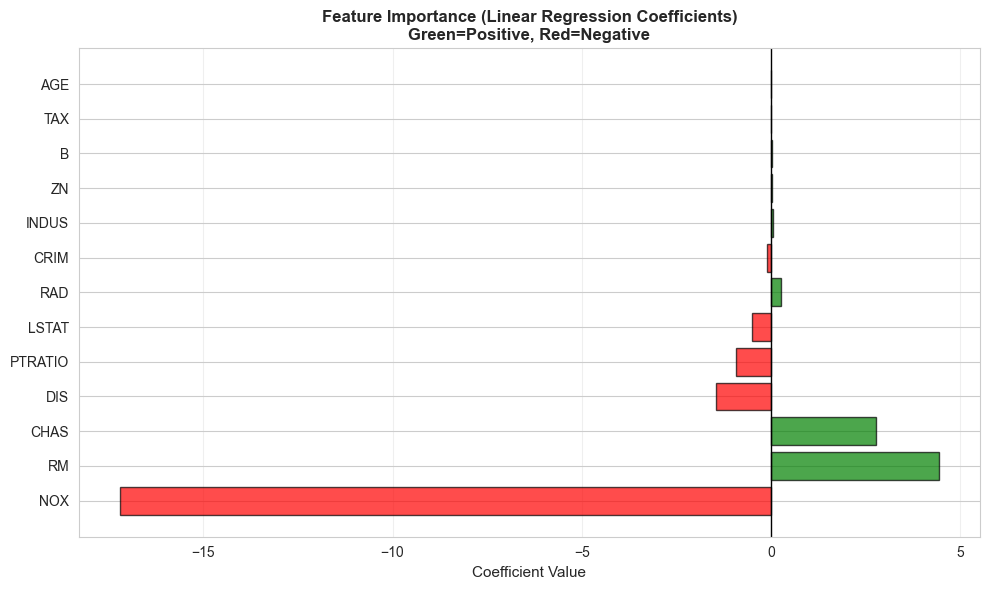

In [ ]:
# Feature importance based on coefficient magnitude
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nFEATURE IMPORTANCE (by coefficient magnitude):")
print(feature_importance.to_string(index=False))

# Visualize Feature Importance
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in feature_importance['Coefficient']]
ax.barh(range(len(feature_importance)), feature_importance['Coefficient'], color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(feature_importance)))
ax.set_yticklabels(feature_importance['Feature'])
ax.set_xlabel('Coefficient Value', fontsize=11)
ax.set_title('Feature Importance (Linear Regression Coefficients)\nGreen=Positive, Red=Negative', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Step 10: Summary and Conclusions

In [ ]:
print("\n" + "=" * 80)
print("MODEL SUMMARY AND INSIGHTS")
print("=" * 80)

print(f"\n1. MODEL PERFORMANCE:")
print(f"   - Test R² Score: {test_r2:.4f} ({test_r2*100:.2f}%)")
print(f"   - Test RMSE: ${test_rmse:.2f}k")
print(f"   - Test MAE: ${test_mae:.2f}k")
print(f"   - Average home value: ${y_test.mean():.2f}k")
print(f"   - Error as % of mean: {(test_mae/y_test.mean())*100:.2f}%")

print(f"\n2. TOP 3 IMPORTANT FEATURES:")
for i, (idx, row) in enumerate(feature_importance.head(3).iterrows(), 1):
    print(f"   {i}. {row['Feature'].strip():8s} → Coefficient: {row['Coefficient']:8.4f}")

print(f"\n3. MODEL GENERALIZATION:")
if abs(train_r2 - test_r2) < 0.05:
    print(f"   ✓ Good generalization (Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f})")
    print(f"   ✓ Model is not overfitting")
else:
    print(f"   ⚠ Possible overfitting (Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f})")

print(f"\n4. RESIDUAL ANALYSIS:")
print(f"   - Training residual mean: {np.mean(train_residuals):.6f} (should be ≈ 0)")
print(f"   - Testing residual mean: {np.mean(test_residuals):.6f} (should be ≈ 0)")
print(f"   - Training residual std: {np.std(train_residuals):.4f}")
print(f"   - Testing residual std: {np.std(test_residuals):.4f}")

print("\n" + "=" * 80)


MODEL SUMMARY AND INSIGHTS

1. MODEL PERFORMANCE:
   - Test R² Score: 0.6688 (66.88%)
   - Test RMSE: $4.93k
   - Test MAE: $3.19k
   - Average home value: $21.49k
   - Error as % of mean: 14.84%

2. TOP 3 IMPORTANT FEATURES:
   1. NOX      → Coefficient: -17.2026
   2. RM       → Coefficient:   4.4388
   3. CHAS     → Coefficient:   2.7844

3. MODEL GENERALIZATION:
   ⚠ Possible overfitting (Train R²: 0.7509, Test R²: 0.6688)

4. RESIDUAL ANALYSIS:
   - Training residual mean: 0.000000 (should be ≈ 0)
   - Testing residual mean: 0.235826 (should be ≈ 0)
   - Training residual std: 4.6520
   - Testing residual std: 4.9230

